In [1]:
import numpy as np         
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings                      #Python'dan kaynaklı hataları kapatmak için:
warnings.filterwarnings("ignore")    

In [3]:
data = pd.read_excel("Nba_data.xlsx")
data

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,462.0,Ty,Lawson,2017-2017,C,CLE,30.0,1.0,11901.0,11901,1,11901.0,2018.0
462,463.0,Lorenzo,Brown,2017-2017,PG,WAS,27.0,1.0,8612.0,8612,1,8612.0,2018.0
463,464.0,Amile,Jefferson,2017-2017,PG,TOR,24.0,1.0,4608.0,4608,1,4608.0,2018.0
464,465.0,Aaron,Jackson,2017-2017,PF,MIN,31.0,1.0,4608.0,4608,1,4608.0,2018.0


> **Elimizdeki veri seti , NBA oyuncularının bilgilerinin olduğu bir veri setidir.**

**VARIABLES**
* **Player ID** : Oyuncu numarası
* **First Name** : Ad
* **Last Name** : Soyad
* **Years** : Sözleşme Yılı
* **Pos** : Pozisyon
* **Team** : Takım
* **Age** : Yaş
* **YEARS** : Takımda Kaç yıl oynandığı
* **DOLLARS** : Alacağı Toplam Maaş
* **GUARANTEED** : Garanti Maaş
* **% GTD** : Oyun Zamanı Kararı - Oyuncunun oynama şansı
* **AVG. SALARY** : Aylık Maaş
* **FREE AGENT** : Sözleşme Bitiş

In [236]:
data.head()

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0


In [237]:
data.columns

Index(['Player ID', 'First Name', 'Last Name', 'Years', 'Pos', 'Team', 'AGE',
       'YEARS', 'DOLLARS', 'GUARANTEED', '% GTD', 'AVG. SALARY', 'FREE AGENT'],
      dtype='object')

In [209]:
data.dtypes

Player ID      float64
First Name      object
Last Name       object
Years           object
Pos             object
Team            object
AGE            float64
YEARS          float64
DOLLARS        float64
GUARANTEED      object
% GTD           object
AVG. SALARY    float64
FREE AGENT     float64
dtype: object

In [210]:
data.ndim

2

In [211]:
data.shape

(466, 13)

In [212]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player ID    465 non-null    float64
 1   First Name   465 non-null    object 
 2   Last Name    465 non-null    object 
 3   Years        465 non-null    object 
 4   Pos          466 non-null    object 
 5   Team         466 non-null    object 
 6   AGE          465 non-null    float64
 7   YEARS        465 non-null    float64
 8   DOLLARS      465 non-null    float64
 9   GUARANTEED   465 non-null    object 
 10  % GTD        465 non-null    object 
 11  AVG. SALARY  465 non-null    float64
 12  FREE AGENT   465 non-null    float64
dtypes: float64(6), object(7)
memory usage: 47.5+ KB


In [238]:
# ilk 10 kayıt
data.head(10)

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
5,6.0,Mike,Conley,2016-2020,PG,MEM,30.0,5.0,152605576.0,140529829,0.9209,30521115.0,2021.0
6,7.0,Joel,Embiid,2018-2022,C,PHI,24.0,5.0,146450000.0,146450000,1,29290000.0,2023.0
7,8.0,Andrew,Wiggins,2018-2022,SG,MIN,23.0,4.0,146450000.0,146450000,1,36612500.0,2023.0
8,9.0,Damian,Lillard,2016-2020,PG,POR,27.0,5.0,139888445.0,139888445,1,27977689.0,2021.0
9,10.0,DeMar,DeRozan,2016-2020,SG,TOR,28.0,5.0,139000000.0,137500000,0.9892,27800000.0,2021.0


In [214]:
# son 10 kayıt
data.tail(10)

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
456,457.0,Damion,Lee,2017-2017,SG,NOP,25.0,1.0,46080.0,46080,1,46080.0,2018.0
457,458.0,David,Stockton,2017-2017,G,ATL,26.0,1.0,44495.0,44495,1,44495.0,2018.0
458,459.0,Jonathan,Gibson,2017-2017,PG,UTH,30.0,1.0,44495.0,44495,1,44495.0,2018.0
459,460.0,Andre,Ingram,2017-2017,PG,BOS,32.0,1.0,13824.0,13824,1,13824.0,2018.0
460,461.0,Kendrick,Perkins,2017-2017,G,LAL,33.0,1.0,13156.0,13156,1,13156.0,2018.0
461,462.0,Ty,Lawson,2017-2017,C,CLE,30.0,1.0,11901.0,11901,1,11901.0,2018.0
462,463.0,Lorenzo,Brown,2017-2017,PG,WAS,27.0,1.0,8612.0,8612,1,8612.0,2018.0
463,464.0,Amile,Jefferson,2017-2017,PG,TOR,24.0,1.0,4608.0,4608,1,4608.0,2018.0
464,465.0,Aaron,Jackson,2017-2017,PF,MIN,31.0,1.0,4608.0,4608,1,4608.0,2018.0
465,NaN,NaN,NaN,NaN,G,HOU,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [239]:
data.loc[5:10,["First Name","Last Name"]] 

,First Name,Last Name
5,Mike,Conley
6,Joel,Embiid
7,Andrew,Wiggins
8,Damian,Lillard
9,DeMar,DeRozan
10,Jrue,Holiday


In [240]:
data.iloc[:50]

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
5,6.0,Mike,Conley,2016-2020,PG,MEM,30.0,5.0,152605576.0,140529829,0.9209,30521115.0,2021.0
6,7.0,Joel,Embiid,2018-2022,C,PHI,24.0,5.0,146450000.0,146450000,1,29290000.0,2023.0
7,8.0,Andrew,Wiggins,2018-2022,SG,MIN,23.0,4.0,146450000.0,146450000,1,36612500.0,2023.0
8,9.0,Damian,Lillard,2016-2020,PG,POR,27.0,5.0,139888445.0,139888445,1,27977689.0,2021.0
9,10.0,DeMar,DeRozan,2016-2020,SG,TOR,28.0,5.0,139000000.0,137500000,0.9892,27800000.0,2021.0


In [241]:
data.drop(["Player ID","YEARS"],axis=1,inplace=False)

,First Name,Last Name,Years,Pos,Team,AGE,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,Russell,Westbrook,2018-2022,PG,OKC,29.0,205030000.0,205030000,1,41006000.0,2023.0
1,Stephen,Curry,2017-2021,PG,GSW,30.0,201158790.0,201158790,1,40231758.0,2022.0
2,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,171174820.0,171174820,1,34234964.0,2022.0
3,James,Harden,2019-2022,SG,HOU,28.0,169344000.0,169344000,1,42336000.0,2023.0
4,John,Wall,2019-2022,PG,WAS,27.0,169344000.0,169344000,1,42336000.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...
461,Ty,Lawson,2017-2017,C,CLE,30.0,11901.0,11901,1,11901.0,2018.0
462,Lorenzo,Brown,2017-2017,PG,WAS,27.0,8612.0,8612,1,8612.0,2018.0
463,Amile,Jefferson,2017-2017,PG,TOR,24.0,4608.0,4608,1,4608.0,2018.0
464,Aaron,Jackson,2017-2017,PF,MIN,31.0,4608.0,4608,1,4608.0,2018.0


In [242]:
data.isnull()

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,False,False,False,False,False,False,False,False,False,False,False,False,False
462,False,False,False,False,False,False,False,False,False,False,False,False,False
463,False,False,False,False,False,False,False,False,False,False,False,False,False
464,False,False,False,False,False,False,False,False,False,False,False,False,False


In [219]:
data.isnull().values.any()

True

In [220]:
data.isnull().any()

Player ID       True
First Name      True
Last Name       True
Years           True
Pos            False
Team           False
AGE             True
YEARS           True
DOLLARS         True
GUARANTEED      True
% GTD           True
AVG. SALARY     True
FREE AGENT      True
dtype: bool

In [221]:
data.isnull().sum()

Player ID      1
First Name     1
Last Name      1
Years          1
Pos            0
Team           0
AGE            1
YEARS          1
DOLLARS        1
GUARANTEED     1
% GTD          1
AVG. SALARY    1
FREE AGENT     1
dtype: int64

In [222]:
data.isnull().values.sum()

11

In [223]:
data.dropna(inplace=False)

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
460,461.0,Kendrick,Perkins,2017-2017,G,LAL,33.0,1.0,13156.0,13156,1,13156.0,2018.0
461,462.0,Ty,Lawson,2017-2017,C,CLE,30.0,1.0,11901.0,11901,1,11901.0,2018.0
462,463.0,Lorenzo,Brown,2017-2017,PG,WAS,27.0,1.0,8612.0,8612,1,8612.0,2018.0
463,464.0,Amile,Jefferson,2017-2017,PG,TOR,24.0,1.0,4608.0,4608,1,4608.0,2018.0


In [243]:
liste1 = [466.0,"Dogukan","Surucu",'2018-2019',21.0,2.0,5000.0,'5000','1',5000.0,2020.0]
liste2 = ["Player ID","First Name","Last Name","Years","AGE","YEARS","DOLLARS","GUARANTEED","% GTD","AVG. SALARY","FREE AGENT"]
birlestirme = zip(liste1,liste2)
for a,b in birlestirme:
    data[[b]] = data[[b]].fillna(value=a,inplace=False)
data

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,Russell,Westbrook,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,Stephen,Curry,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,Blake,Griffin,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,James,Harden,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,John,Wall,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,462.0,Ty,Lawson,2017-2017,C,CLE,30.0,1.0,11901.0,11901,1,11901.0,2018.0
462,463.0,Lorenzo,Brown,2017-2017,PG,WAS,27.0,1.0,8612.0,8612,1,8612.0,2018.0
463,464.0,Amile,Jefferson,2017-2017,PG,TOR,24.0,1.0,4608.0,4608,1,4608.0,2018.0
464,465.0,Aaron,Jackson,2017-2017,PF,MIN,31.0,1.0,4608.0,4608,1,4608.0,2018.0


In [272]:
data["First Name"] = data["First Name"].str.upper()
data["Last Name"] = data["Last Name"].str.upper()
data

,Player ID,First Name,Last Name,Years,Pos,Team,AGE,YEARS,DOLLARS,GUARANTEED,% GTD,AVG. SALARY,FREE AGENT
0,1.0,RUSSELL,WESTBROOK,2018-2022,PG,OKC,29.0,5.0,205030000.0,205030000,1,41006000.0,2023.0
1,2.0,STEPHEN,CURRY,2017-2021,PG,GSW,30.0,5.0,201158790.0,201158790,1,40231758.0,2022.0
2,3.0,BLAKE,GRIFFIN,2017-2021,PF,DETSigned w/LAC,29.0,5.0,171174820.0,171174820,1,34234964.0,2022.0
3,4.0,JAMES,HARDEN,2019-2022,SG,HOU,28.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
4,5.0,JOHN,WALL,2019-2022,PG,WAS,27.0,4.0,169344000.0,169344000,1,42336000.0,2023.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,462.0,TY,LAWSON,2017-2017,C,CLE,30.0,1.0,11901.0,11901,1,11901.0,2018.0
462,463.0,LORENZO,BROWN,2017-2017,PG,WAS,27.0,1.0,8612.0,8612,1,8612.0,2018.0
463,464.0,AMILE,JEFFERSON,2017-2017,PG,TOR,24.0,1.0,4608.0,4608,1,4608.0,2018.0
464,465.0,AARON,JACKSON,2017-2017,PF,MIN,31.0,1.0,4608.0,4608,1,4608.0,2018.0


In [265]:
data.describe()

,Player ID,AGE,YEARS,DOLLARS,AVG. SALARY,FREE AGENT
count,466.000000,466.000000,466.000000,4.660000e+02,4.660000e+02,466.000000
mean,233.500000,26.553648,2.929185,2.682711e+07,7.365849e+06,1997.675966
std,134.666873,4.285800,1.186540,3.648790e+07,8.400297e+06,208.272774
min,1.000000,19.000000,1.000000,4.608000e+03,4.608000e+03,0.000000
25%,117.250000,23.000000,2.000000,3.214690e+06,1.472708e+06,2018.000000
50%,233.500000,26.000000,3.000000,9.077700e+06,3.379370e+06,2019.000000
75%,349.750000,29.000000,4.000000,4.100000e+07,1.143028e+07,2020.000000
max,466.000000,41.000000,5.000000,2.050300e+08,4.233600e+07,2023.000000


In [249]:
# toplam kaç kayıt vardır ?
len(data["Player ID"])

466

In [250]:
# bütün oyuncuların toplam maaş ortalaması nedir
data["DOLLARS"].mean()

26827111.916309014

In [252]:
# tüm oyuncuların toplam maaş ortalamasının altına kalan oyuncuların isim soyisim ve aldıkları maaşlar nedir ?
data[data["DOLLARS"]<data["DOLLARS"].mean()][["First Name","Last Name","DOLLARS"]]

,First Name,Last Name,DOLLARS
145,KARL-ANTHONY,TOWNS,25720035.0
146,C.J.,MILES,25000000.0
147,ANDREW,WIGGINS,24850243.0
148,ZACH,RANDOLPH,24000000.0
149,GARRETT,TEMPLE,24000000.0
...,...,...,...
461,TY,LAWSON,11901.0
462,LORENZO,BROWN,8612.0
463,AMILE,JEFFERSON,4608.0
464,AARON,JACKSON,4608.0


In [254]:
#en yüksek maaş ne kadardır ?
data["DOLLARS"].max()

205030000.0

In [5]:
#en düşük maaş ne kadardır ?
data["DOLLARS"].min()

4608.0

In [256]:
#6  en yüksek maaş alan oyuncu kimdir 
data[data["DOLLARS"] == data["DOLLARS"].max()][["First Name","Last Name","Pos","DOLLARS"]]

,First Name,Last Name,Pos,DOLLARS
0,RUSSELL,WESTBROOK,PG,205030000.0


In [262]:
# yaşı 20-25 arasında olan oyuncuların isim ve oynadıkları takımlar nedir ?
data[(data.AGE<=25) & (data.AGE>=20)][["Team","First Name","Last Name","AGE"]]

,Team,First Name,Last Name,AGE
6,PHI,JOEL,EMBIID,24.0
7,MIN,ANDREW,WIGGINS,23.0
12,NOP,ANTHONY,DAVIS,25.0
13,WAS,BRADLEY,BEAL,24.0
14,DET,ANDRE,DRUMMOND,24.0
...,...,...,...,...
452,POR,YOGI,FERRELL,24.0
454,LAL,AARON,HARRISON,23.0
456,NOP,DAMION,LEE,25.0
463,TOR,AMILE,JEFFERSON,24.0


In [274]:
# " Wade Baldwin " isimli oyuncunun oynadığ takım hangisidir 
data[data["First Name"] == "WADE"][["First Name","Last Name","Team"]]

,First Name,Last Name,Team
451,WADE,BALDWIN,OKC


In [277]:
#9  takımlara göre oyuncuların maaşlarının ortalaması,standart sapması ve takımın max-min maaş bilgisi nedir ?
data.groupby("Team")[["DOLLARS"]].aggregate([np.mean,np.std,"max","min"])

DOLLARS                                       
                         mean           std          max         min
Team                                                                
ATL              1.408883e+07  2.396796e+07   70000000.0     44495.0
ATLSigned w/MIL  5.000000e+07           NaN   50000000.0  50000000.0
BKN              8.267627e+06  1.221532e+07   38300000.0   1974159.0
BKNSigned w/LAL  4.350899e+07  2.897867e+07   64000000.0  23017978.0
BKNSigned w/NOP  2.262871e+06           NaN    2262871.0   2262871.0
...                       ...           ...          ...         ...
UTHSigned w/MIN  5.500000e+07           NaN   55000000.0  55000000.0
WAS              5.034936e+07  5.670641e+07  169344000.0      8612.0
WASSigned w/BKN  3.749640e+06           NaN    3749640.0   3749640.0
WASSigned w/NOP  4.075500e+06           NaN    4075500.0   4075500.0
WASSigned w/PHX  3.200000e+07           NaN   32000000.0  32000000.0

[103 rows x 4 columns]

In [278]:
#10  kaç farklı takım vardır ?
len(data.groupby("Team"))


# 2.yol: 

# data["Team"].value_counts().count()

103

In [279]:
#11  kaç takımda kaç oyuncu vardır ?
data.groupby("Team").aggregate(np.size).iloc[:,:2]

,Player ID,First Name
Team,,
ATL,14,14
ATLSigned w/MIL,1,1
BKN,8,8
BKNSigned w/LAL,2,2
BKNSigned w/NOP,1,1
...,...,...
UTHSigned w/MIN,1,1
WAS,13,13
WASSigned w/BKN,1,1


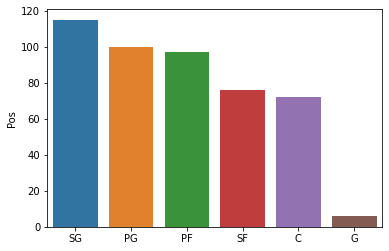

In [289]:
sns.barplot(x = data.Pos.value_counts().index, y = data.Pos.value_counts());

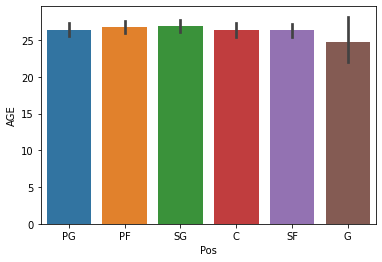

In [306]:
sns.barplot(x = "Pos" , y = "AGE" , data = data);

In [305]:
data[data["Pos"]=="G"][["AGE"]].mean()

AGE    24.666667
dtype: float64

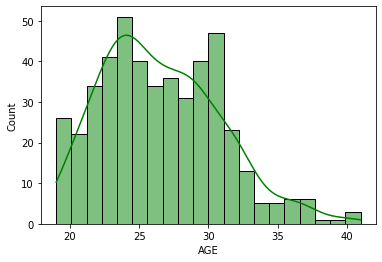

In [4]:
sns.histplot(data = data ,x = "AGE",kde=True,bins=20,color="green");

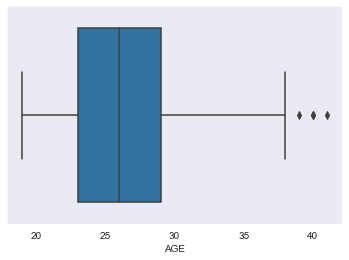

In [34]:
sns.boxplot(x = data.AGE);

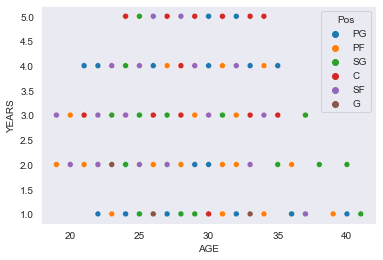

In [51]:
sns.scatterplot(data = data,x = "AGE", y = "YEARS" , hue="Pos");